# 01 — Exploratory Data Analysis & Power BI Data Preparation


1. Khám phá dataset 
2. Phân tích phân phối lớp (Class Imbalance)
3. Phân tích Amount, Time và Feature Correlation ( độ tương quan của đặc trưng )
4. Xuất dữ liệu cho **Power BI**
5. Nạp dữ liệu vào PostgreSQL

In [2]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATA_FILE, REPORTS_DIR

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

print(f'Data file: {DATA_FILE}')
print(f'Reports dir: {REPORTS_DIR}')

Data file: /Users/tienmacncheese/antgrav/Credit card fraud detection/Machine Learning/data/creditcard.csv
Reports dir: /Users/tienmacncheese/antgrav/Credit card fraud detection/Machine Learning/reports


## 1. Load Dataset

In [3]:
from src.preprocessing import load_data

df = load_data()
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Thông tin tổng quan
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
# Kiểm tra missing values
print('Missing values per column:')
print(df.isnull().sum().sum())  # Expects 0
print(f'\nDuplicates: {df.duplicated().sum()}')

Missing values per column:
0

Duplicates: 1081


## 2. Phân phối lớp (Class Distribution)

Legitimate (0): 284,315 (99.827%)
Fraud (1):      492 (0.173%)


/var/folders/07/2c6q616j2nvbtfhnr3ldwms80000gn/T/ipykernel_56820/2442150744.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Legitimate', 'Fraud'], y=class_counts.values, ax=axes[0],


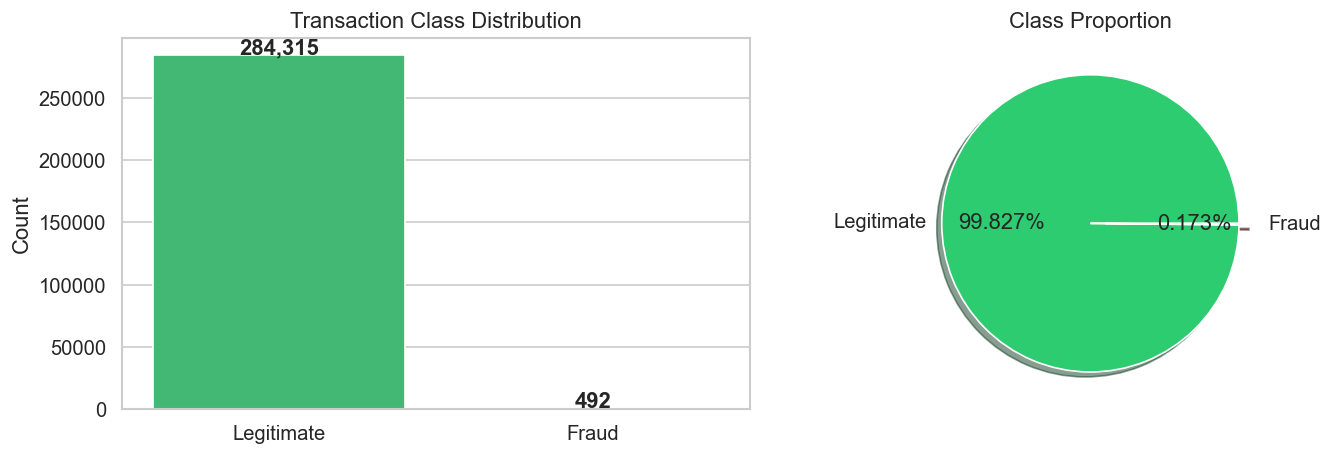

In [5]:
class_counts = df['Class'].value_counts()
print(f'Legitimate (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.3f}%)')
print(f'Fraud (1):      {class_counts[1]:,} ({class_counts[1]/len(df)*100:.3f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.barplot(x=['Legitimate', 'Fraud'], y=class_counts.values, ax=axes[0], 
            palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'], 
            autopct='%1.3f%%', colors=['#2ecc71', '#e74c3c'],
            explode=[0, 0.1], shadow=True)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'eda_class_distribution.png'))
plt.show()

Tập dữ liệu mất cân bằng . 

## 3. Phân phối số tiền và thời gian (Amount and Time)

Text(0.5, 1.0, 'Distribution of Time')

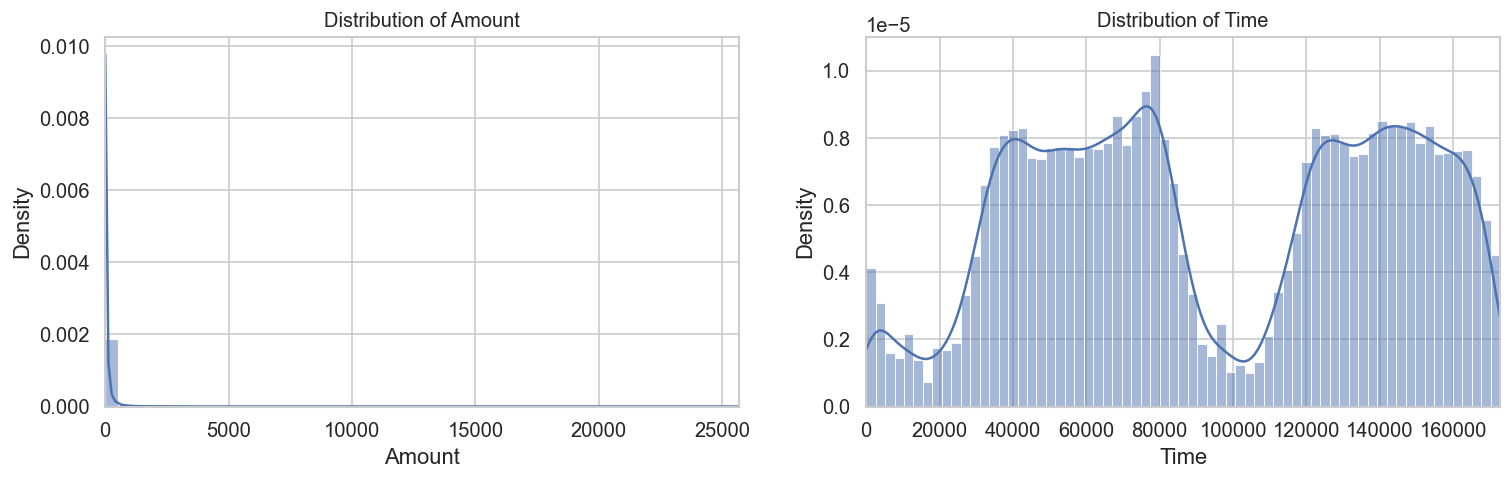

In [4]:
# Check the feature 'Amount' and 'Time'
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15,4))

ax1 = sns.histplot(ax=ax1, x='Amount', data=df, stat='density', bins=50, kde=True)
ax1.set_xlim(min(df['Amount']), max(df['Amount']))
ax1.set_title('Distribution of Amount', fontsize=12)

ax2 = sns.histplot(ax=ax2, x='Time', data=df, stat='density', kde=True)
ax2.set_xlim(min(df['Time']), max(df['Time'])) 
ax2.set_title('Distribution of Time', fontsize=12)

Theo biểu đồ trên, phần lớn các giao dịch có giá trị nhỏ. Tuy nhiên, đáng chú ý là phân phối này có độ biến thiên rất lớn, với số tiền giao dịch tối đa vượt quá 25.000.

## 3.1. Tương quan giữa các đặc trưng

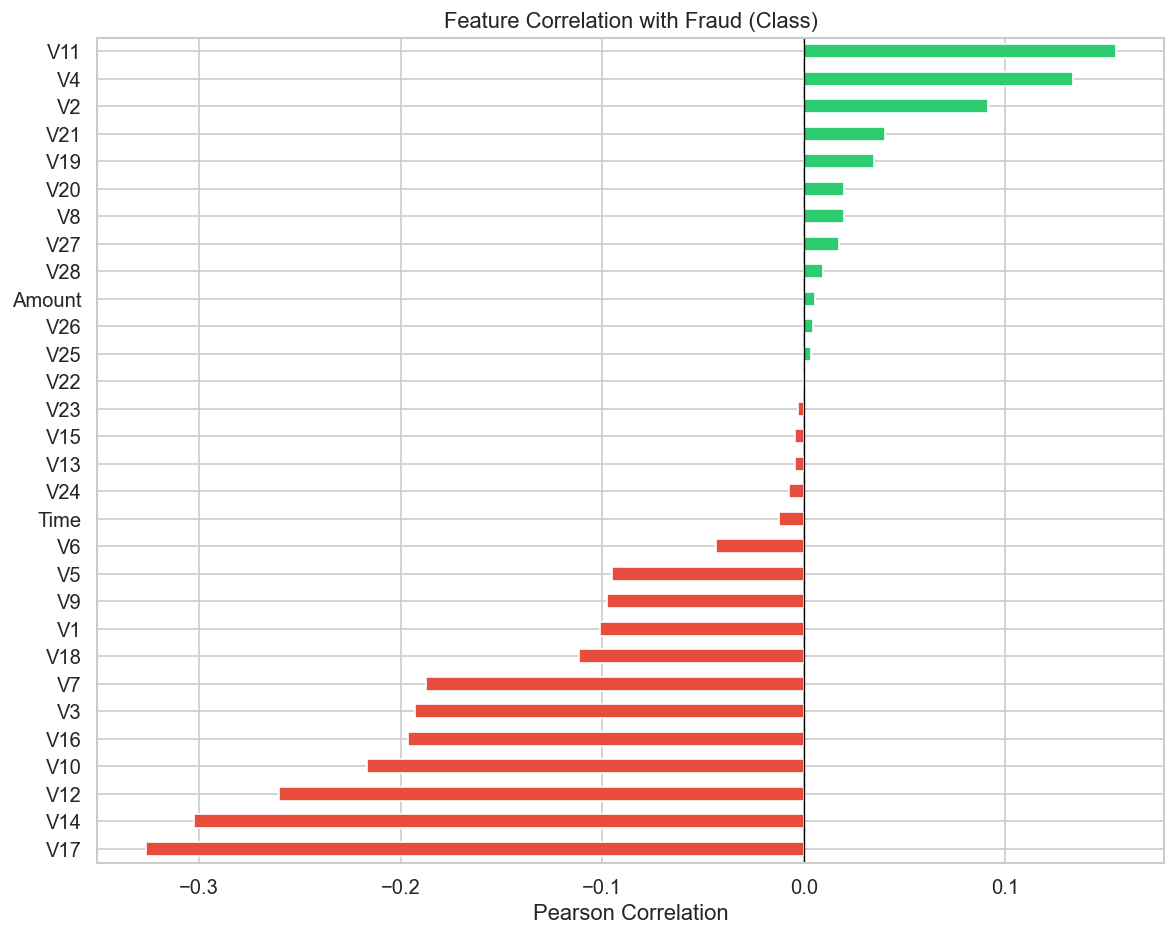


Top positive correlations with Fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top negative correlations with Fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [7]:
# Correlation with target
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlations.values]
correlations.plot.barh(ax=ax, color=colors)
ax.set_title('Feature Correlation with Fraud (Class)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'eda_correlation.png'))
plt.show()

print('\nTop positive correlations with Fraud:')
print(correlations.tail(5))
print('\nTop negative correlations with Fraud:')
print(correlations.head(5))

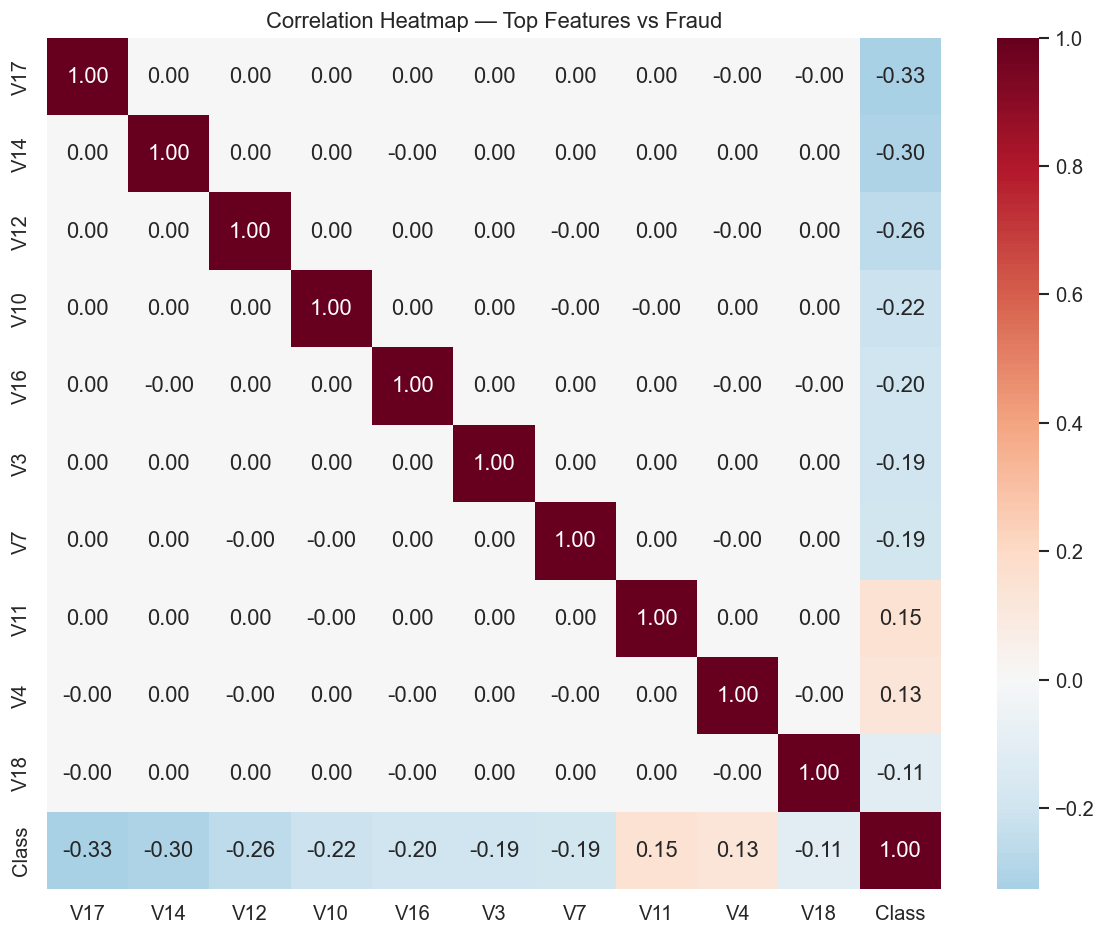

In [8]:
# Heatmap of strongly correlated features
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('Class')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Top Features vs Fraud')

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'eda_heatmap.png'))
plt.show()

Trong khi các đặc trưng từ V1 đến V28 cho thấy mối tương quan không đáng kể giữa chúng với nhau, đáng chú ý là có một số mối tương quan khi xem xét các đặc trưng này cùng với Time (Thời gian), Amount (Số tiền) và Class (Biến mục tiêu):

*Time có mối tương quan nghịch với V3.

*Amount có mối tương quan thuận với V7 và V20, trong khi cho thấy mối tương quan nghịch với V2 và V5.

*Class cho thấy mối tương quan nghịch rõ rệt với V17 và V14, tương quan thuận với V11 và V4.

## 3.2. Phân phối giữa cá Đặc Trưng 

So sánh phân phối V1–V28 giữa 2 lớp để xem PCA components nào giúp phân biệt fraud.

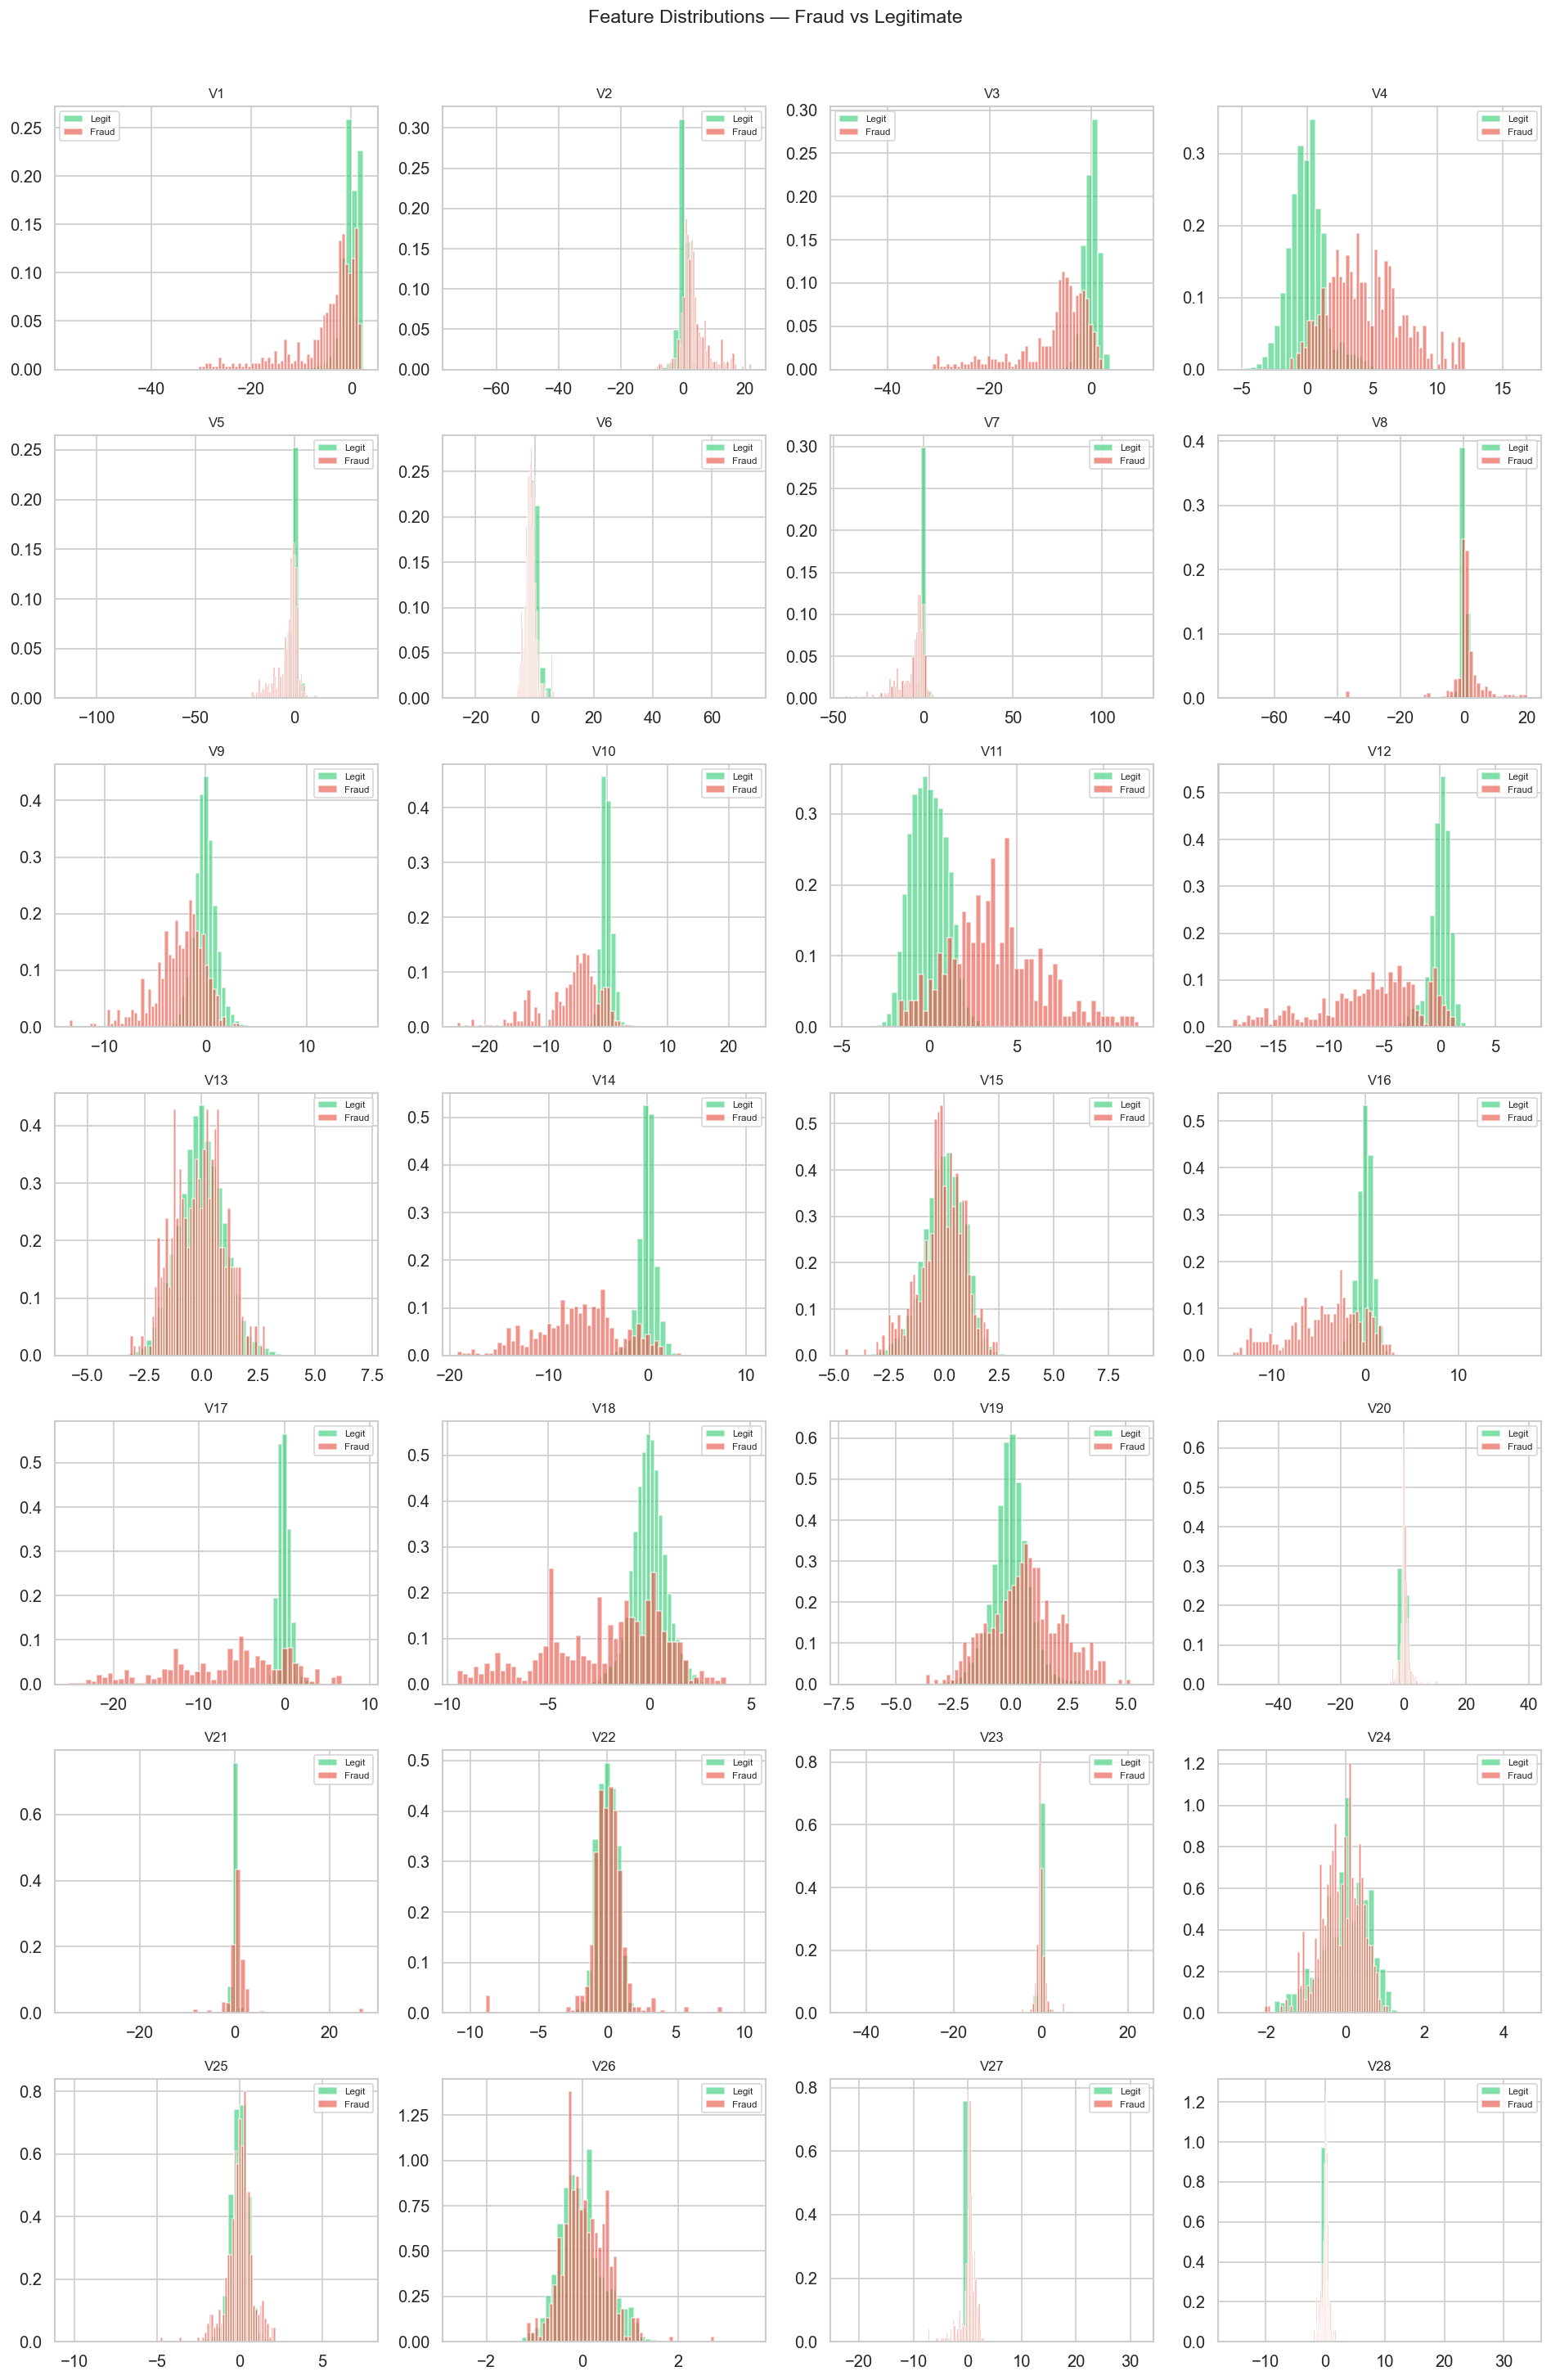

In [9]:
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    ax = axes[i]
    ax.hist(df[df['Class'] == 0][feat], bins=50, alpha=0.6, label='Legit', color='#2ecc71', density=True)
    ax.hist(df[df['Class'] == 1][feat], bins=50, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions — Fraud vs Legitimate', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'eda_feature_distributions.png'))
plt.show()

## 4. Export Cleaned Data for Power BI

Xuất file CSV đã chuẩn hoá để Power BI có thể import trực tiếp làm dashboard **"Dữ liệu trước huấn luyện"**.

In [10]:
from src.preprocessing import scale_features

# Scale Amount & Time cho Power BI
df_scaled = scale_features(df, fit=True)

# Thêm cột label text cho dễ đọc trong Power BI
df_scaled['Class_Label'] = df_scaled['Class'].map({0: 'Legitimate', 1: 'Fraud'})

# Export
export_path = REPORTS_DIR / 'eda_cleaned_for_powerbi.csv'
df_scaled.to_csv(export_path, index=False)
print(f'✅ Exported cleaned data → {export_path}')
print(f'   Shape: {df_scaled.shape}')
print(f'   Size: {export_path.stat().st_size / 1e6:.1f} MB')

✅ Exported cleaned data → /Users/tienmacncheese/antgrav/Credit card fraud detection/Machine Learning/reports/eda_cleaned_for_powerbi.csv
   Shape: (284807, 32)
   Size: 161.3 MB


In [11]:
# Cũng xuất bảng tóm tắt thống kê cho Power BI
summary = df.describe().T
summary['feature'] = summary.index
summary.to_csv(REPORTS_DIR / 'eda_summary_statistics.csv', index=False)
print('✅ Exported summary statistics for Power BI')

✅ Exported summary statistics for Power BI


## 5. PostgreSQL



In [ ]:
# import os
# os.environ['DB_HOST'] = 'localhost'
# os.environ['DB_PORT'] = '5432'
# os.environ['DB_NAME'] = 'fraud_detection'
# os.environ['DB_USER'] = 'postgres'
# os.environ['DB_PASSWORD'] = 'your_password'

# from src.db_utils import get_connection, create_tables
# conn = get_connection()
# create_tables(conn)
# print('✅ PostgreSQL tables created!')
# conn.close()